
=== SIGNAL SUMMARY ===
Model:
 - Rolling regression fair value
 - Predictors: VEGA, CERES, TERRA, SOLACE
 - Regression window: 126 days
 - Entry z-score: 1.65
 - Exit z-score: 0.5
 - Volatility filter: False
 - Transaction cost: 0.0005

Spread statistics:
Observations: 1874
Mean spread:  -0.1571
Std spread:   1.8685
Half-life:    7.00 days
Median phi:   0.8820

Z-score excursion counts:
|z| > 1.5: 329
|z| > 1.65: 254
|z| > 2.0: 137

=== ROLLING COEFFICIENT SUMMARY ===
           mean      std      min       max
const   29.1907  28.0892 -28.0553  115.5281
VEGA     0.2227   0.0956   0.0469    0.4291
CERES    0.1616   0.1111  -0.0232    0.4669
TERRA    0.2700   0.4911  -1.3661    1.7703
SOLACE   0.3521   0.4865  -0.8045    1.7588

=== FULL-SAMPLE PERFORMANCE ===
Annualised Sharpe: 2.1790
Total PnL:         22.7342
Average daily PnL: 0.014025
Daily PnL std:     0.102175
Entries:           45
Exits:             44

=== PERFORMANCE SUMMARY ===
Return Metrics:
Total PnL:              22.7342

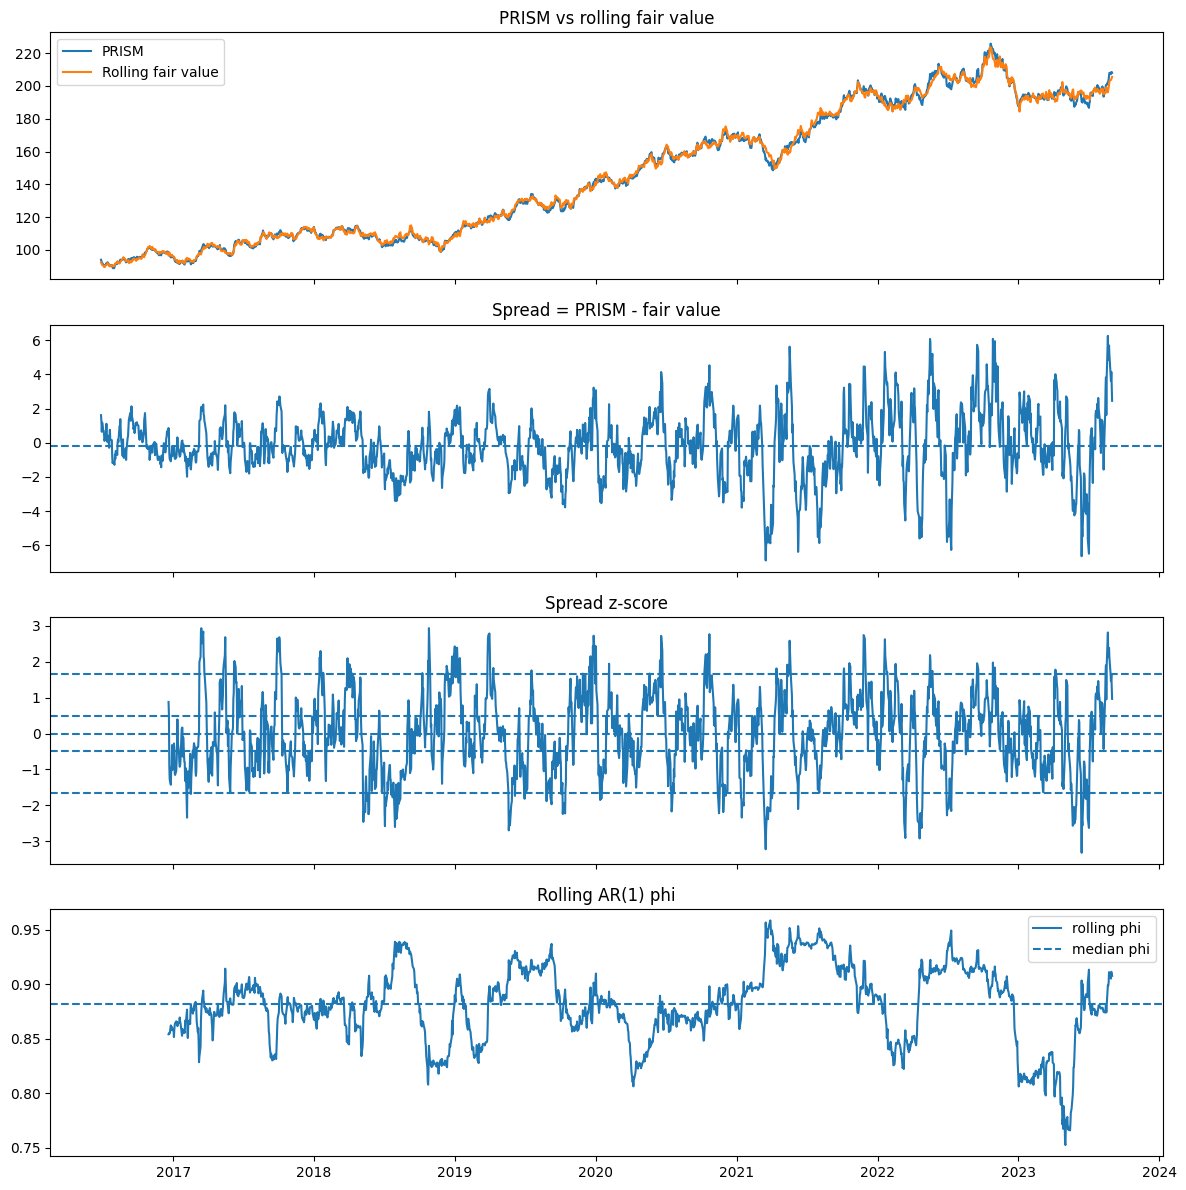

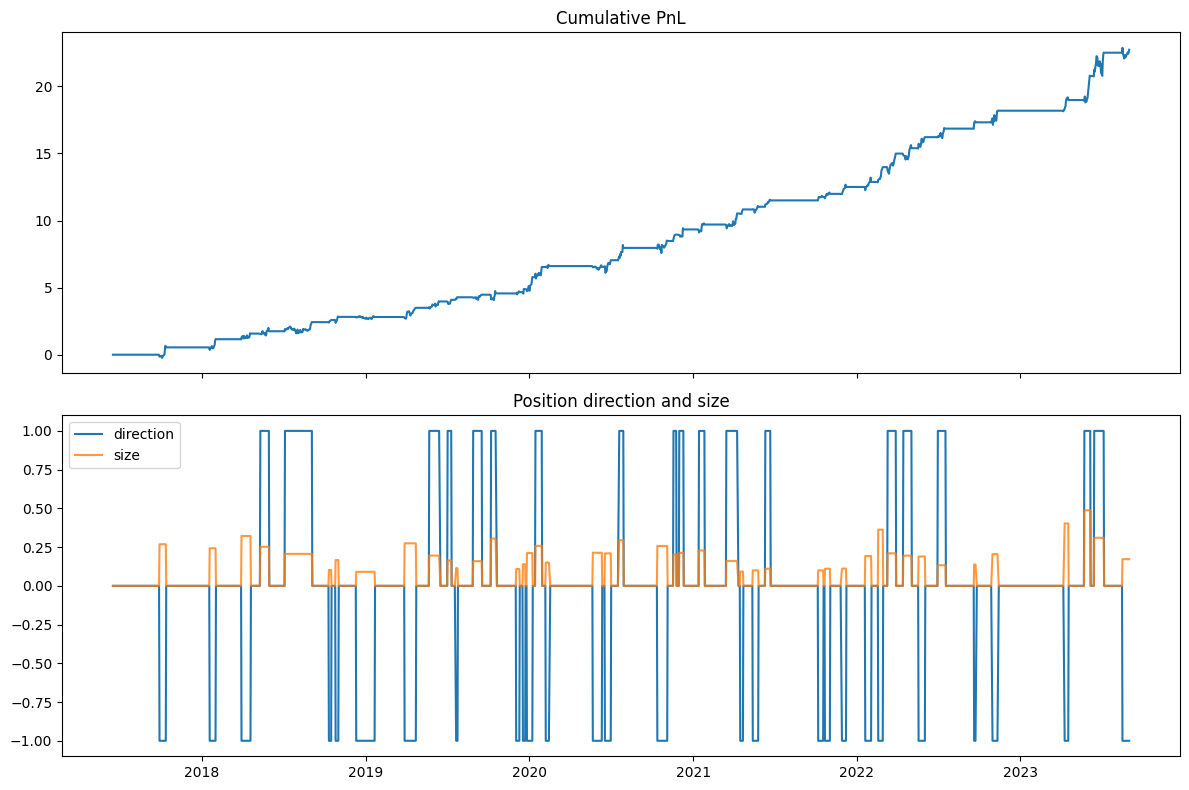

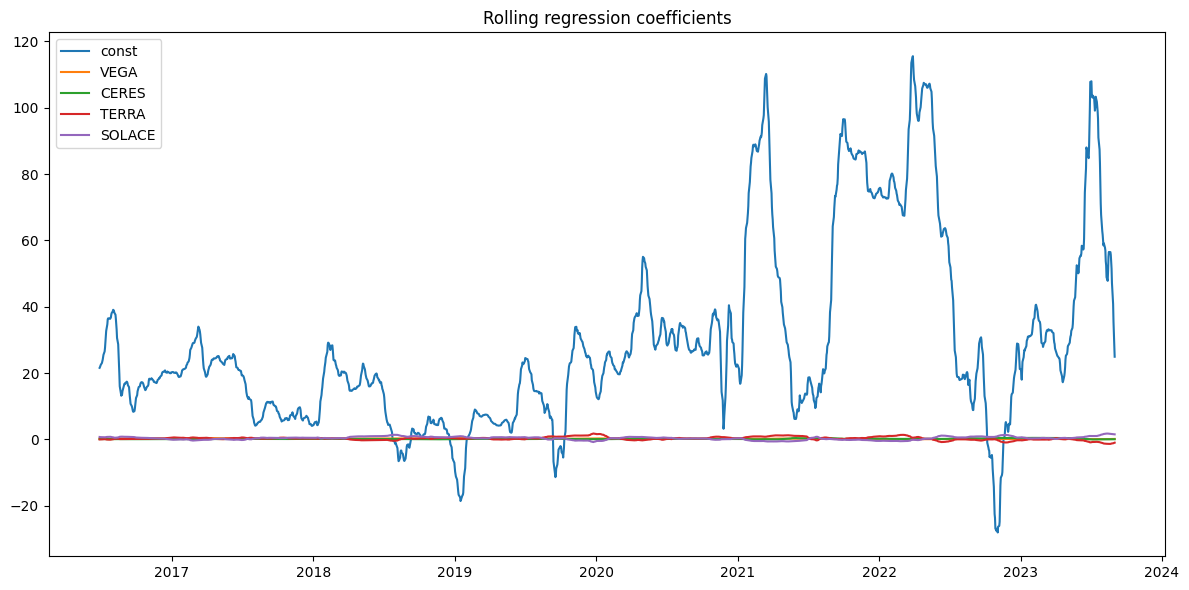

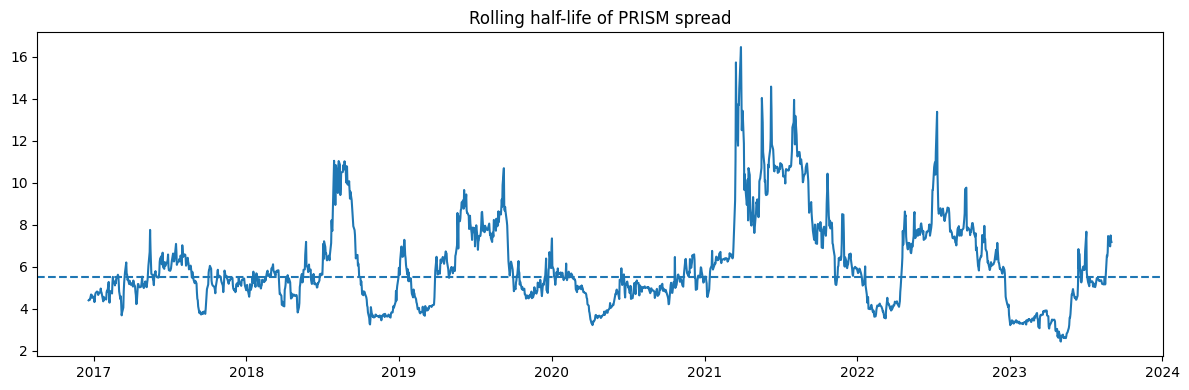


=== FINAL MODEL ===
Regression window: 126
Entry z-score: 1.65
Exit z-score: 0.5
Volatility filter: False
Position sizing: expected reversion / spread std


In [1]:
import warnings
warnings.filterwarnings("ignore")

from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


# =========================================================
# CONFIG
# =========================================================

CSV_PATH = "datathon_train.csv"

TARGET = "PRISM"
PREDICTORS = ["VEGA", "CERES", "TERRA", "SOLACE"]

# Final model choice
REG_WINDOW = 126
ZSCORE_WINDOW = 126
VOL_SHORT_WINDOW = 30
VOL_LONG_WINDOW = 252
PHI_WINDOW = 126

ENTRY_Z = 1.65
EXIT_Z = 0.5
USE_VOL_FILTER = False   # retained only for reporting consistency

COST_RATE = 0.0005
MAX_HOLDING_DAYS = 60
MAX_ABS_POSITION = 2.0

MIN_VOL_RATIO = 0.75
MAX_VOL_RATIO = 1.75

TEST_SIZE = 500


# =========================================================
# DATA
# =========================================================

def load_prices(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")

    df = df.sort_index()
    prices = df.select_dtypes(include=[np.number]).copy()

    required = [TARGET] + PREDICTORS
    missing = [c for c in required if c not in prices.columns]
    if missing:
        raise ValueError("Missing columns: {}".format(missing))

    return prices


# =========================================================
# CORE HELPERS
# =========================================================

def fit_ols(y: pd.Series, X: pd.DataFrame):
    X_const = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X_const).fit()
    return model


def estimate_phi(series: pd.Series) -> float:
    s = series.dropna()
    if len(s) < 10:
        return np.nan

    lag = s.shift(1)
    aligned = pd.concat([s, lag], axis=1).dropna()
    aligned.columns = ["s", "lag"]

    y = aligned["s"].values
    x = aligned["lag"].values
    X = np.column_stack([np.ones(len(x)), x])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(beta[1])


def estimate_half_life(series: pd.Series) -> float:
    phi = estimate_phi(series)
    if np.isnan(phi) or phi <= 0 or phi >= 1:
        return np.inf
    return float(-np.log(2) / np.log(phi))


def rolling_phi(spread: pd.Series, window: int) -> pd.Series:
    values = []
    idx = []

    for end in range(window, len(spread) + 1):
        sub = spread.iloc[end - window:end]
        phi = estimate_phi(sub)
        values.append(phi)
        idx.append(spread.index[end - 1])

    return pd.Series(values, index=idx)


# =========================================================
# SIGNAL CONSTRUCTION
# =========================================================

def build_rolling_signal(prices: pd.DataFrame, reg_window: int = REG_WINDOW) -> pd.DataFrame:
    rows = []

    for t in range(reg_window, len(prices)):
        train = prices.iloc[t - reg_window:t]
        today = prices.iloc[t]

        y_train = train[TARGET]
        X_train = train[PREDICTORS]

        model = fit_ols(y_train, X_train)

        fair_value = model.params["const"]
        for p in PREDICTORS:
            fair_value += model.params[p] * today[p]

        spread = today[TARGET] - fair_value

        row = {
            "Date": prices.index[t],
            "prism": today[TARGET],
            "fair_value": fair_value,
            "spread": spread,
            "const": model.params["const"],
        }

        for p in PREDICTORS:
            row[p] = model.params[p]

        rows.append(row)

    signal = pd.DataFrame(rows).set_index("Date")

    signal["spread_change"] = signal["spread"].diff()
    signal["spread_mean"] = signal["spread"].rolling(ZSCORE_WINDOW).mean()
    signal["spread_std"] = signal["spread"].rolling(ZSCORE_WINDOW).std()
    signal["z"] = (signal["spread"] - signal["spread_mean"]) / signal["spread_std"]

    signal["short_vol"] = signal["spread_change"].rolling(VOL_SHORT_WINDOW).std()
    signal["long_vol"] = signal["spread_change"].rolling(VOL_LONG_WINDOW).std()
    signal["vol_ratio"] = (signal["short_vol"] / signal["long_vol"]).clip(
        lower=MIN_VOL_RATIO,
        upper=MAX_VOL_RATIO
    )

    phi_series = rolling_phi(signal["spread"], PHI_WINDOW)
    signal = signal.join(phi_series.rename("phi"))

    # Expected next-step reversion in the spread
    signal["expected_reversion"] = -(1.0 - signal["phi"]) * signal["spread"]

    return signal


# =========================================================
# BACKTEST
# =========================================================

def compute_position_size(expected_reversion: float,
                          spread_std: float,
                          max_abs_position: float = MAX_ABS_POSITION) -> float:
    if pd.isna(expected_reversion) or pd.isna(spread_std) or spread_std <= 0:
        return 0.0

    score = abs(expected_reversion) / spread_std
    return float(min(score, max_abs_position))


def backtest_strategy(signal: pd.DataFrame,
                      entry_z: float = ENTRY_Z,
                      exit_z: float = EXIT_Z,
                      cost_rate: float = COST_RATE,
                      max_holding_days: int = MAX_HOLDING_DAYS,
                      max_abs_position: float = MAX_ABS_POSITION) -> Tuple[pd.DataFrame, float]:
    df = signal.copy().dropna().copy()

    pnl = []
    direction_hist = []
    size_hist = []
    entry_hist = []
    exit_hist = []
    dates = []

    current_dir = 0
    current_size = 0.0
    holding_days = 0

    for t in range(len(df) - 1):
        today = df.iloc[t]
        tomorrow = df.iloc[t + 1]

        z_today = today["z"]
        spread_today = today["spread"]
        spread_tomorrow = tomorrow["spread"]
        expected_reversion_today = today["expected_reversion"]

        new_dir = current_dir
        new_size = current_size
        entry_flag = 0
        exit_flag = 0

        if current_dir == 0:
            if z_today < -entry_z:
                new_dir = 1
                new_size = compute_position_size(
                    expected_reversion=expected_reversion_today,
                    spread_std=today["spread_std"],
                    max_abs_position=max_abs_position
                )
                holding_days = 0
                entry_flag = 1

            elif z_today > entry_z:
                new_dir = -1
                new_size = compute_position_size(
                    expected_reversion=expected_reversion_today,
                    spread_std=today["spread_std"],
                    max_abs_position=max_abs_position
                )
                holding_days = 0
                entry_flag = 1

        else:
            holding_days += 1
            exit_now = False

            if current_dir == 1 and z_today >= -exit_z:
                exit_now = True
            elif current_dir == -1 and z_today <= exit_z:
                exit_now = True
            elif max_holding_days is not None and holding_days >= max_holding_days:
                exit_now = True

            if exit_now:
                new_dir = 0
                new_size = 0.0
                holding_days = 0
                exit_flag = 1

        gross_pnl = current_dir * current_size * (spread_tomorrow - spread_today)

        turnover = abs(new_dir * new_size - current_dir * current_size)
        cost = turnover * cost_rate * abs(today["prism"])

        net_pnl = gross_pnl - cost

        pnl.append(net_pnl)
        direction_hist.append(current_dir)
        size_hist.append(current_size)
        entry_hist.append(entry_flag)
        exit_hist.append(exit_flag)
        dates.append(df.index[t + 1])

        current_dir = new_dir
        current_size = new_size

    result = pd.DataFrame({
        "pnl": pnl,
        "direction": direction_hist,
        "size": size_hist,
        "entry": entry_hist,
        "exit": exit_hist,
    }, index=dates)

    result["cum_pnl"] = result["pnl"].cumsum()

    daily_mean = result["pnl"].mean()
    daily_std = result["pnl"].std()
    sharpe = np.nan if daily_std == 0 else float((daily_mean / daily_std) * np.sqrt(252))

    return result, sharpe


# =========================================================
# SUMMARIES
# =========================================================

def summarize_signal(signal: pd.DataFrame) -> None:
    spread = signal["spread"].dropna()
    z = signal["z"].dropna()
    phi = signal["phi"].dropna()

    print("\n=== SIGNAL SUMMARY ===")
    print("Model:")
    print(" - Rolling regression fair value")
    print(" - Predictors: {}".format(", ".join(PREDICTORS)))
    print(" - Regression window: {} days".format(REG_WINDOW))
    print(" - Entry z-score: {}".format(ENTRY_Z))
    print(" - Exit z-score: {}".format(EXIT_Z))
    print(" - Volatility filter: {}".format(USE_VOL_FILTER))
    print(" - Transaction cost: {:.4f}".format(COST_RATE))

    print("\nSpread statistics:")
    print("Observations: {}".format(len(signal)))
    print("Mean spread:  {:.4f}".format(spread.mean()))
    print("Std spread:   {:.4f}".format(spread.std()))
    print("Half-life:    {:.2f} days".format(estimate_half_life(spread)))
    print("Median phi:   {:.4f}".format(phi.median()))

    print("\nZ-score excursion counts:")
    print("|z| > 1.5: {}".format(int((z.abs() > 1.5).sum())))
    print("|z| > 1.65: {}".format(int((z.abs() > 1.65).sum())))
    print("|z| > 2.0: {}".format(int((z.abs() > 2.0).sum())))


def summarize_coefficients(signal: pd.DataFrame) -> None:
    coef_cols = ["const"] + PREDICTORS
    summary = signal[coef_cols].agg(["mean", "std", "min", "max"]).T

    print("\n=== ROLLING COEFFICIENT SUMMARY ===")
    print(summary.round(4).to_string())


def summarize_backtest(result: pd.DataFrame, sharpe: float, label: str) -> None:
    print("\n=== {} ===".format(label))
    print("Annualised Sharpe: {:.4f}".format(sharpe))
    print("Total PnL:         {:.4f}".format(result["pnl"].sum()))
    print("Average daily PnL: {:.6f}".format(result["pnl"].mean()))
    print("Daily PnL std:     {:.6f}".format(result["pnl"].std()))
    print("Entries:           {}".format(int(result["entry"].sum())))
    print("Exits:             {}".format(int(result["exit"].sum())))


def performance_stats(result: pd.DataFrame) -> None:
    pnl = result["pnl"].dropna()

    total_pnl = pnl.sum()
    mean_daily = pnl.mean()
    std_daily = pnl.std()

    sharpe = np.nan
    if std_daily > 0:
        sharpe = (mean_daily / std_daily) * np.sqrt(252)

    cumulative = pnl.cumsum()
    drawdown = cumulative - cumulative.cummax()
    max_drawdown = drawdown.min()

    wins = (pnl > 0).sum()
    losses = (pnl < 0).sum()
    total_nonzero = wins + losses
    win_rate = wins / total_nonzero if total_nonzero > 0 else np.nan

    avg_win = pnl[pnl > 0].mean() if wins > 0 else np.nan
    avg_loss = pnl[pnl < 0].mean() if losses > 0 else np.nan

    gross_profit = pnl[pnl > 0].sum()
    gross_loss = abs(pnl[pnl < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    print("\n=== PERFORMANCE SUMMARY ===")
    print("Return Metrics:")
    print("Total PnL:              {:.4f}".format(total_pnl))
    print("Average Daily PnL:      {:.6f}".format(mean_daily))
    print("Daily PnL Std:          {:.6f}".format(std_daily))
    print("Annualised Sharpe:      {:.4f}".format(sharpe))

    print("\nRisk Metrics:")
    print("Max Drawdown:           {:.4f}".format(max_drawdown))

    print("\nTrade Statistics:")
    print("Number of Trades:       {}".format(int(result["entry"].sum())))
    print("Win Rate:               {:.2%}".format(win_rate) if not np.isnan(win_rate) else "Win Rate:               nan")
    print("Average Win:            {:.6f}".format(avg_win) if not np.isnan(avg_win) else "Average Win:            nan")
    print("Average Loss:           {:.6f}".format(avg_loss) if not np.isnan(avg_loss) else "Average Loss:           nan")
    print("Profit Factor:          {:.2f}".format(profit_factor) if not np.isnan(profit_factor) else "Profit Factor:          nan")


# =========================================================
# ROBUSTNESS CHECKS
# =========================================================

def train_test_split_signal(signal: pd.DataFrame, test_size: int = TEST_SIZE):
    signal = signal.dropna().copy()
    train = signal.iloc[:-test_size].copy()
    test = signal.iloc[-test_size:].copy()
    return train, test


def parameter_sanity_check(signal: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for entry_z in [1.5, 1.6, 1.65, 1.7, 1.8]:
        result, sharpe = backtest_strategy(signal, entry_z=entry_z, exit_z=EXIT_Z)
        rows.append({
            "entry_z": entry_z,
            "sharpe": sharpe,
            "total_pnl": result["pnl"].sum(),
            "entries": int(result["entry"].sum()),
        })

    out = pd.DataFrame(rows)
    print("\n=== PARAMETER SANITY CHECK ===")
    print(out.to_string(index=False))
    return out


def delay_test(signal: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for delay_days in [0, 1, 2]:
        delayed = signal.copy()
        delayed["z"] = delayed["z"].shift(delay_days)
        delayed["spread_std"] = delayed["spread_std"].shift(delay_days)
        delayed["expected_reversion"] = delayed["expected_reversion"].shift(delay_days)

        result, sharpe = backtest_strategy(delayed, entry_z=ENTRY_Z, exit_z=EXIT_Z)

        rows.append({
            "delay_days": delay_days,
            "sharpe": sharpe,
            "total_pnl": result["pnl"].sum(),
            "entries": int(result["entry"].sum()),
        })

    out = pd.DataFrame(rows)
    print("\n=== EXECUTION DELAY TEST ===")
    print(out.to_string(index=False))
    return out


def noise_test(prices: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for noise_std in [0.0005, 0.0010, 0.0020]:
        sharpes = []

        for seed in [1, 2, 3, 4, 5]:
            rng = np.random.default_rng(seed)
            noisy_prices = prices.copy()
            eps = rng.normal(0.0, noise_std, size=len(noisy_prices))
            noisy_prices[TARGET] = noisy_prices[TARGET] * (1.0 + eps)

            noisy_signal = build_rolling_signal(noisy_prices, reg_window=REG_WINDOW)
            _, sharpe = backtest_strategy(noisy_signal, entry_z=ENTRY_Z, exit_z=EXIT_Z)
            sharpes.append(sharpe)

        rows.append({
            "noise_std": noise_std,
            "mean_sharpe": float(np.mean(sharpes)),
            "min_sharpe": float(np.min(sharpes)),
            "max_sharpe": float(np.max(sharpes)),
        })

    out = pd.DataFrame(rows)
    print("\n=== NOISE ROBUSTNESS TEST ===")
    print(out.to_string(index=False))
    return out


def rolling_half_life_summary(signal: pd.DataFrame) -> pd.DataFrame:
    spread = signal["spread"].dropna()
    rows = []

    for end in range(PHI_WINDOW, len(spread) + 1):
        sub = spread.iloc[end - PHI_WINDOW:end]
        rows.append({
            "Date": sub.index[-1],
            "half_life": estimate_half_life(sub),
        })

    out = pd.DataFrame(rows).set_index("Date")

    summary = pd.DataFrame([{
        "median_half_life": float(out["half_life"].median()),
        "mean_half_life": float(out["half_life"].mean()),
        "min_half_life": float(out["half_life"].min()),
        "max_half_life": float(out["half_life"].max()),
    }])

    print("\n=== ROLLING HALF-LIFE SUMMARY ===")
    print(summary.to_string(index=False))

    return out


# =========================================================
# PLOTS
# =========================================================

def plot_main_diagnostics(signal: pd.DataFrame) -> None:
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axes[0].plot(signal.index, signal["prism"], label="PRISM")
    axes[0].plot(signal.index, signal["fair_value"], label="Rolling fair value")
    axes[0].legend()
    axes[0].set_title("PRISM vs rolling fair value")

    axes[1].plot(signal.index, signal["spread"])
    axes[1].axhline(signal["spread"].mean(), linestyle="--")
    axes[1].set_title("Spread = PRISM - fair value")

    axes[2].plot(signal.index, signal["z"])
    axes[2].axhline(ENTRY_Z, linestyle="--")
    axes[2].axhline(-ENTRY_Z, linestyle="--")
    axes[2].axhline(EXIT_Z, linestyle="--")
    axes[2].axhline(-EXIT_Z, linestyle="--")
    axes[2].axhline(0, linestyle="--")
    axes[2].set_title("Spread z-score")

    axes[3].plot(signal.index, signal["phi"], label="rolling phi")
    axes[3].axhline(signal["phi"].median(), linestyle="--", label="median phi")
    axes[3].legend()
    axes[3].set_title("Rolling AR(1) phi")

    plt.tight_layout()
    plt.show()


def plot_backtest(result: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(result.index, result["cum_pnl"])
    axes[0].set_title("Cumulative PnL")

    axes[1].plot(result.index, result["direction"], label="direction")
    axes[1].plot(result.index, result["size"], label="size", alpha=0.8)
    axes[1].legend()
    axes[1].set_title("Position direction and size")

    plt.tight_layout()
    plt.show()


def plot_rolling_coefficients(signal: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 6))
    plt.plot(signal.index, signal["const"], label="const")
    for p in PREDICTORS:
        plt.plot(signal.index, signal[p], label=p)
    plt.title("Rolling regression coefficients")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_rolling_half_life(hl_df: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 4))
    plt.plot(hl_df.index, hl_df["half_life"])
    plt.axhline(hl_df["half_life"].median(), linestyle="--")
    plt.title("Rolling half-life of PRISM spread")
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================

def main() -> None:
    prices = load_prices(CSV_PATH)
    signal = build_rolling_signal(prices, reg_window=REG_WINDOW)

    # Signal description
    summarize_signal(signal)
    summarize_coefficients(signal)

    # Main backtest
    full_result, full_sharpe = backtest_strategy(signal, entry_z=ENTRY_Z, exit_z=EXIT_Z)
    summarize_backtest(full_result, full_sharpe, "FULL-SAMPLE PERFORMANCE")
    performance_stats(full_result)

    # Train/test split
    train_signal, test_signal = train_test_split_signal(signal, test_size=TEST_SIZE)
    train_result, train_sharpe = backtest_strategy(train_signal, entry_z=ENTRY_Z, exit_z=EXIT_Z)
    test_result, test_sharpe = backtest_strategy(test_signal, entry_z=ENTRY_Z, exit_z=EXIT_Z)

    summarize_backtest(train_result, train_sharpe, "TRAIN WINDOW")
    summarize_backtest(test_result, test_sharpe, "TEST WINDOW")

    # Fundamental robustness checks
    parameter_sanity_check(signal)
    delay_test(signal)
    noise_test(prices)
    hl_df = rolling_half_life_summary(signal)

    # Plots
    plot_main_diagnostics(signal)
    plot_backtest(full_result)
    plot_rolling_coefficients(signal)
    plot_rolling_half_life(hl_df)

    print("\n=== FINAL MODEL ===")
    print("Regression window: {}".format(REG_WINDOW))
    print("Entry z-score: {}".format(ENTRY_Z))
    print("Exit z-score: {}".format(EXIT_Z))
    print("Volatility filter: {}".format(USE_VOL_FILTER))
    print("Position sizing: expected reversion / spread std")


if __name__ == "__main__":
    main()